/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change(period)
/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change(period)
/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leadin

Dropped 0.5% entries from factor data: 0.5% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 100.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-2129.726807,159.384003,-66.271674,105.214041,15385,21.041906
2,-296.574768,204.295990,11.588260,88.700429,14230,19.462224
3,-246.101562,218.857208,53.636940,84.099957,14172,19.382898
4,-204.534866,249.638596,93.726291,79.316951,14230,19.462224
5,-154.461487,389.430328,158.603304,75.942844,15099,20.650747


Returns Analysis


,1D,5D,10D
Ann. alpha,0.186,0.190,0.198
beta,-0.012,-0.002,0.019
Mean Period Wise Return Top Quantile (bps),9.692,9.474,10.071
Mean Period Wise Return Bottom Quantile (bps),-3.492,-5.853,-6.886
Mean Period Wise Spread (bps),13.184,15.037,16.536


<Figure size 640x480 with 0 Axes>

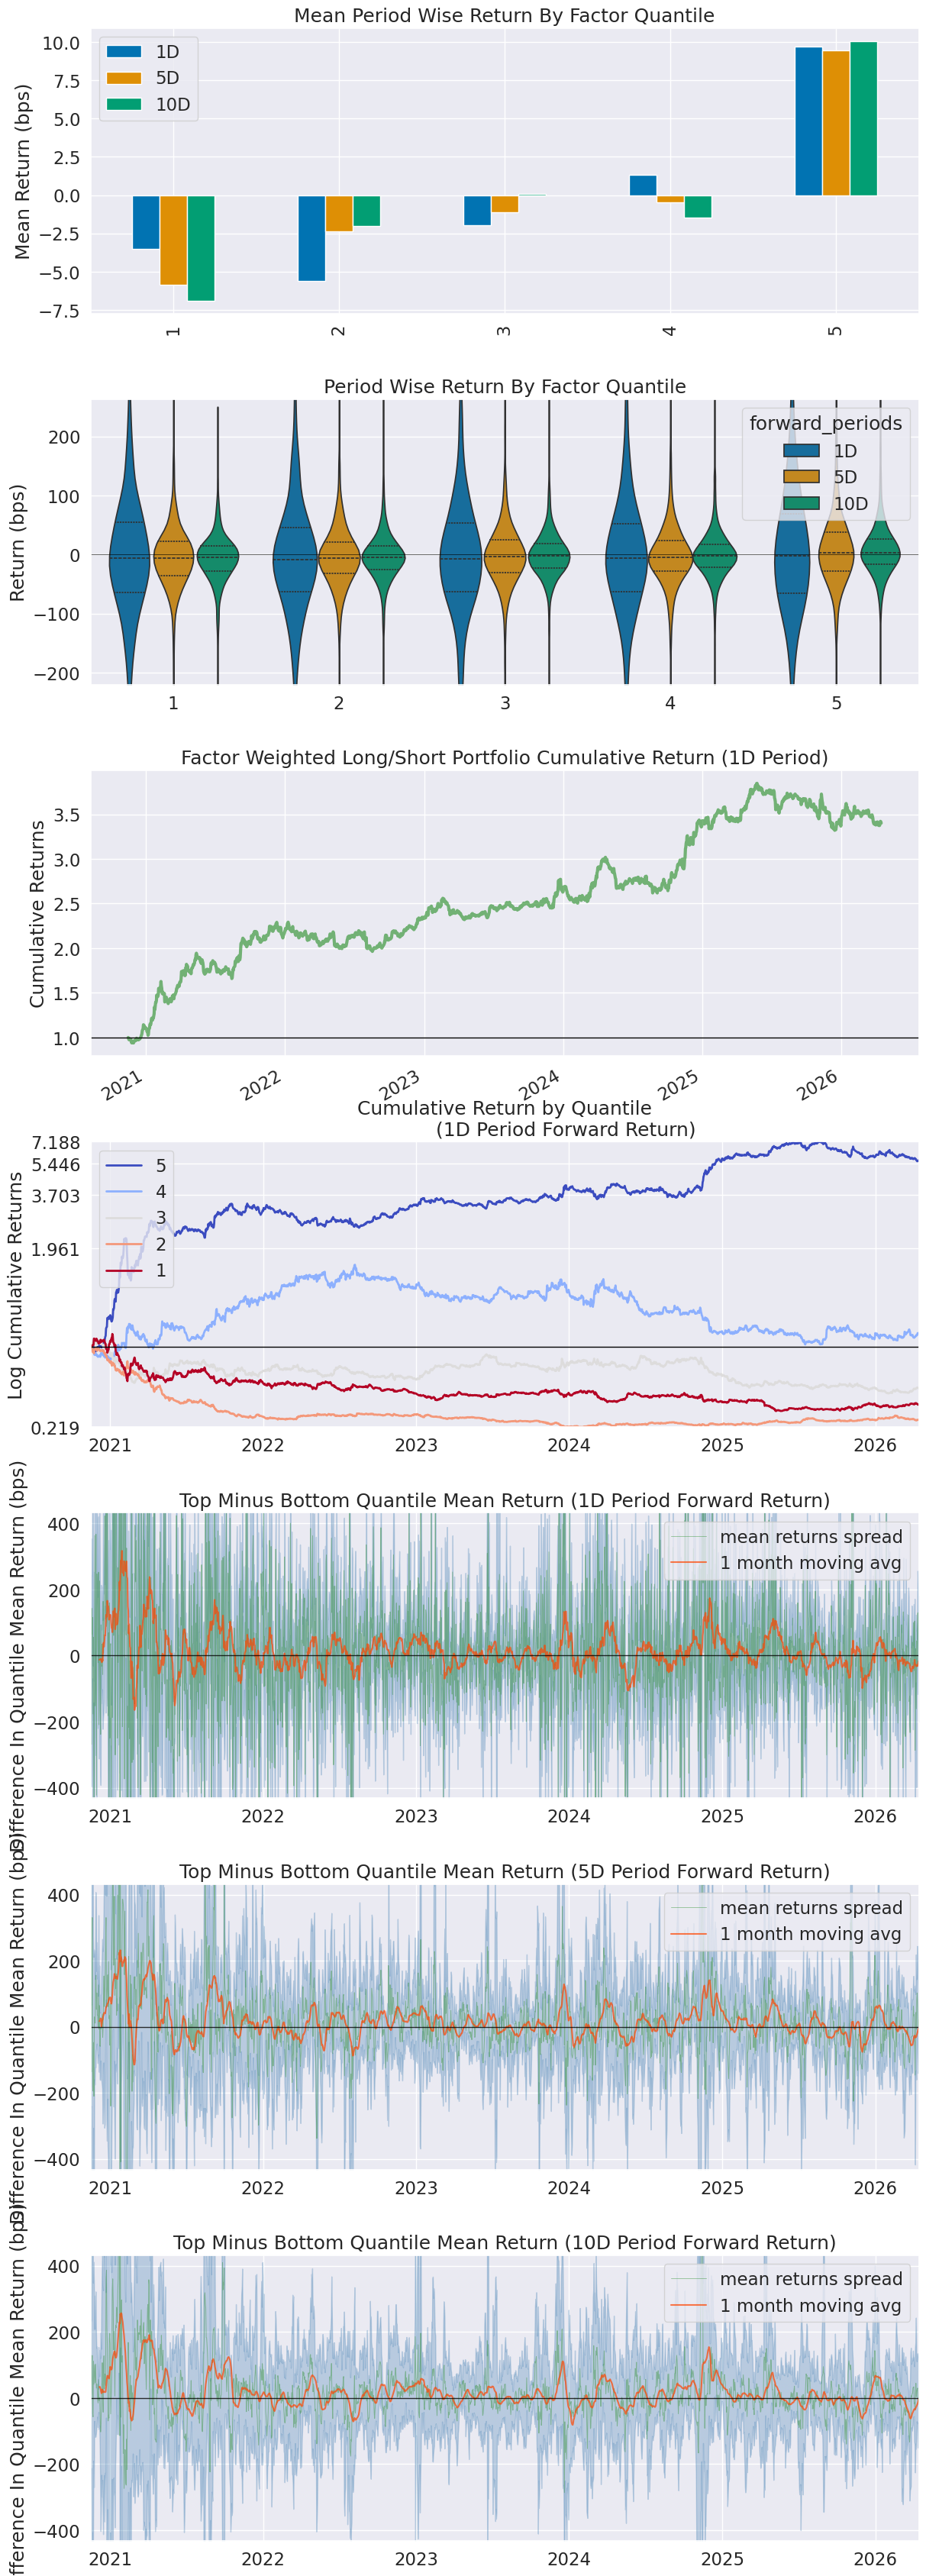

Information Analysis


,1D,5D,10D
IC Mean,0.001,0.007,0.017
IC Std.,0.199,0.202,0.197
Risk-Adjusted IC,0.003,0.036,0.084
t-stat(IC),0.115,1.614,3.743
p-value(IC),0.908,0.107,0.000
IC Skew,-0.039,-0.031,-0.098
IC Kurtosis,-0.175,-0.216,-0.135


/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/performance.py:118: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  grouper.append(pd.Grouper(freq=by_time))


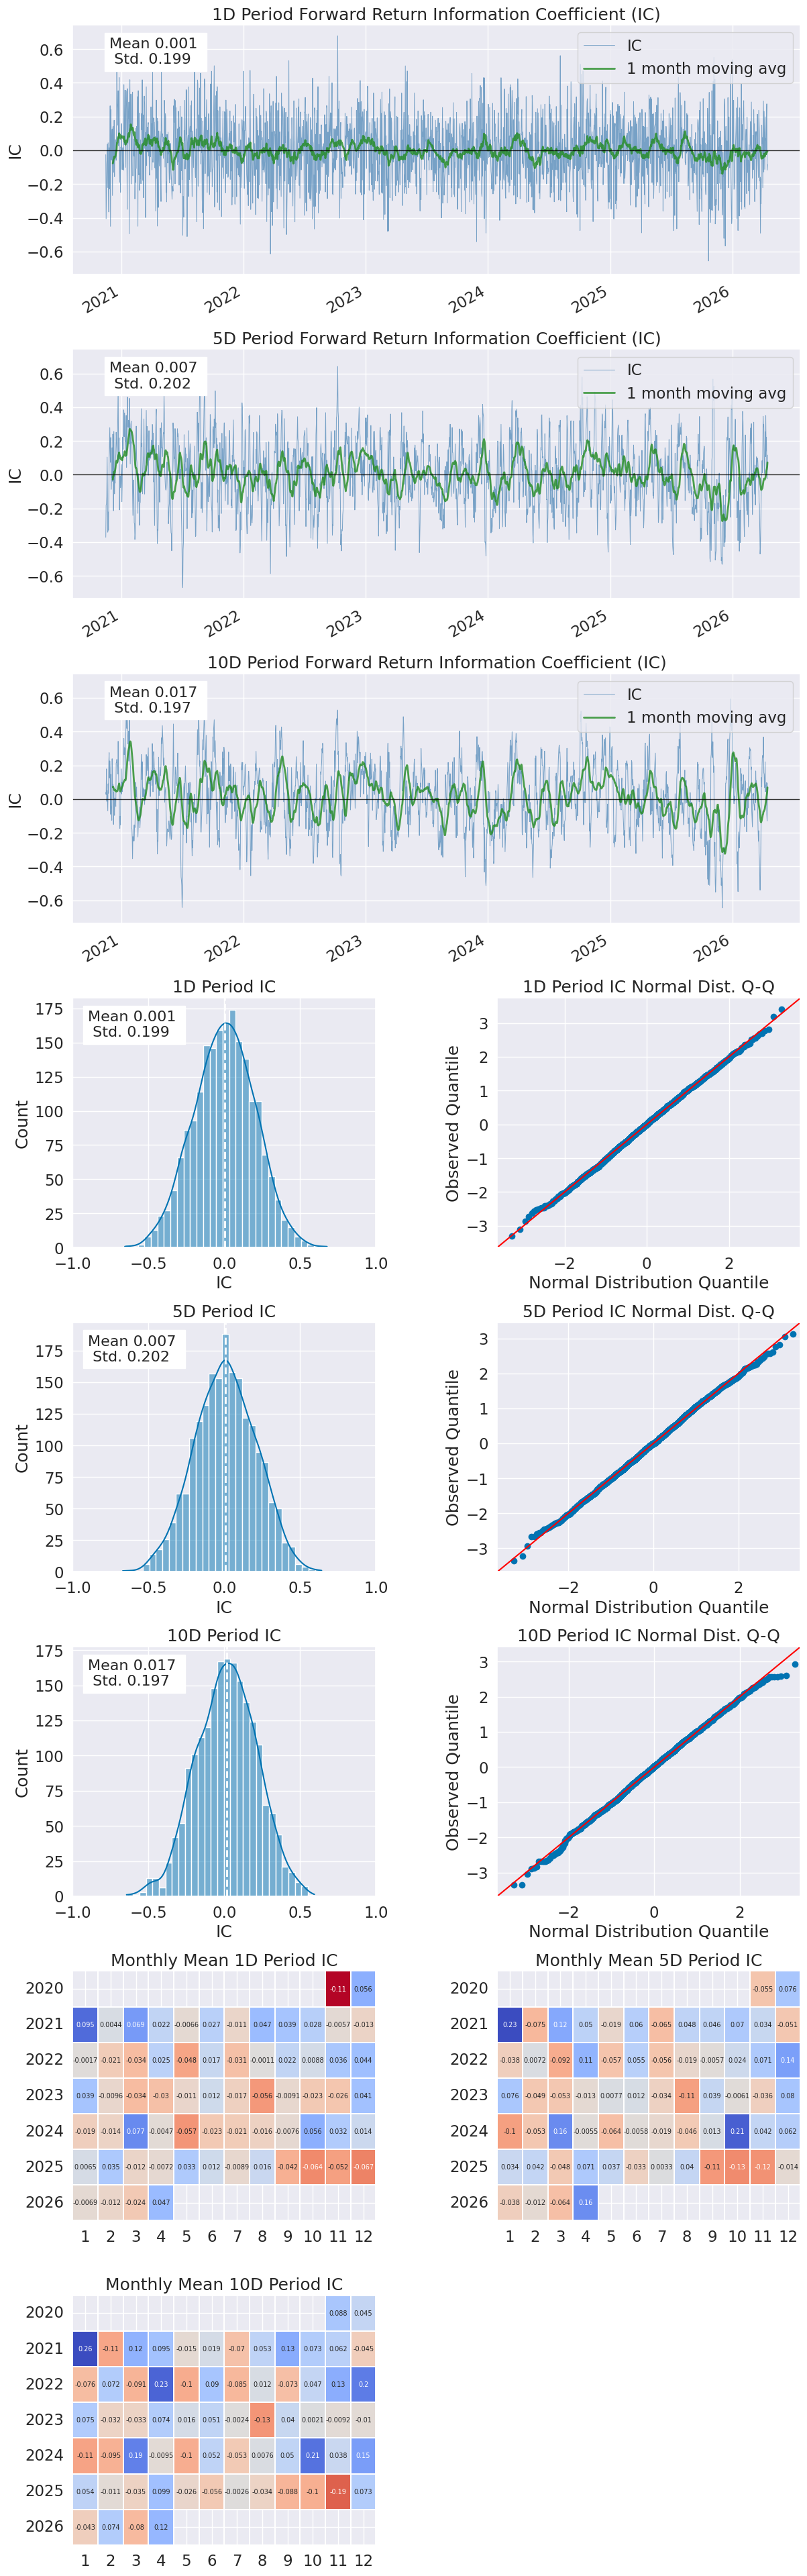

/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.114,0.351,0.539
Quantile 2 Mean Turnover,0.256,0.610,0.740
Quantile 3 Mean Turnover,0.291,0.655,0.761
Quantile 4 Mean Turnover,0.260,0.627,0.743
Quantile 5 Mean Turnover,0.124,0.390,0.586


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.978,0.786,0.508


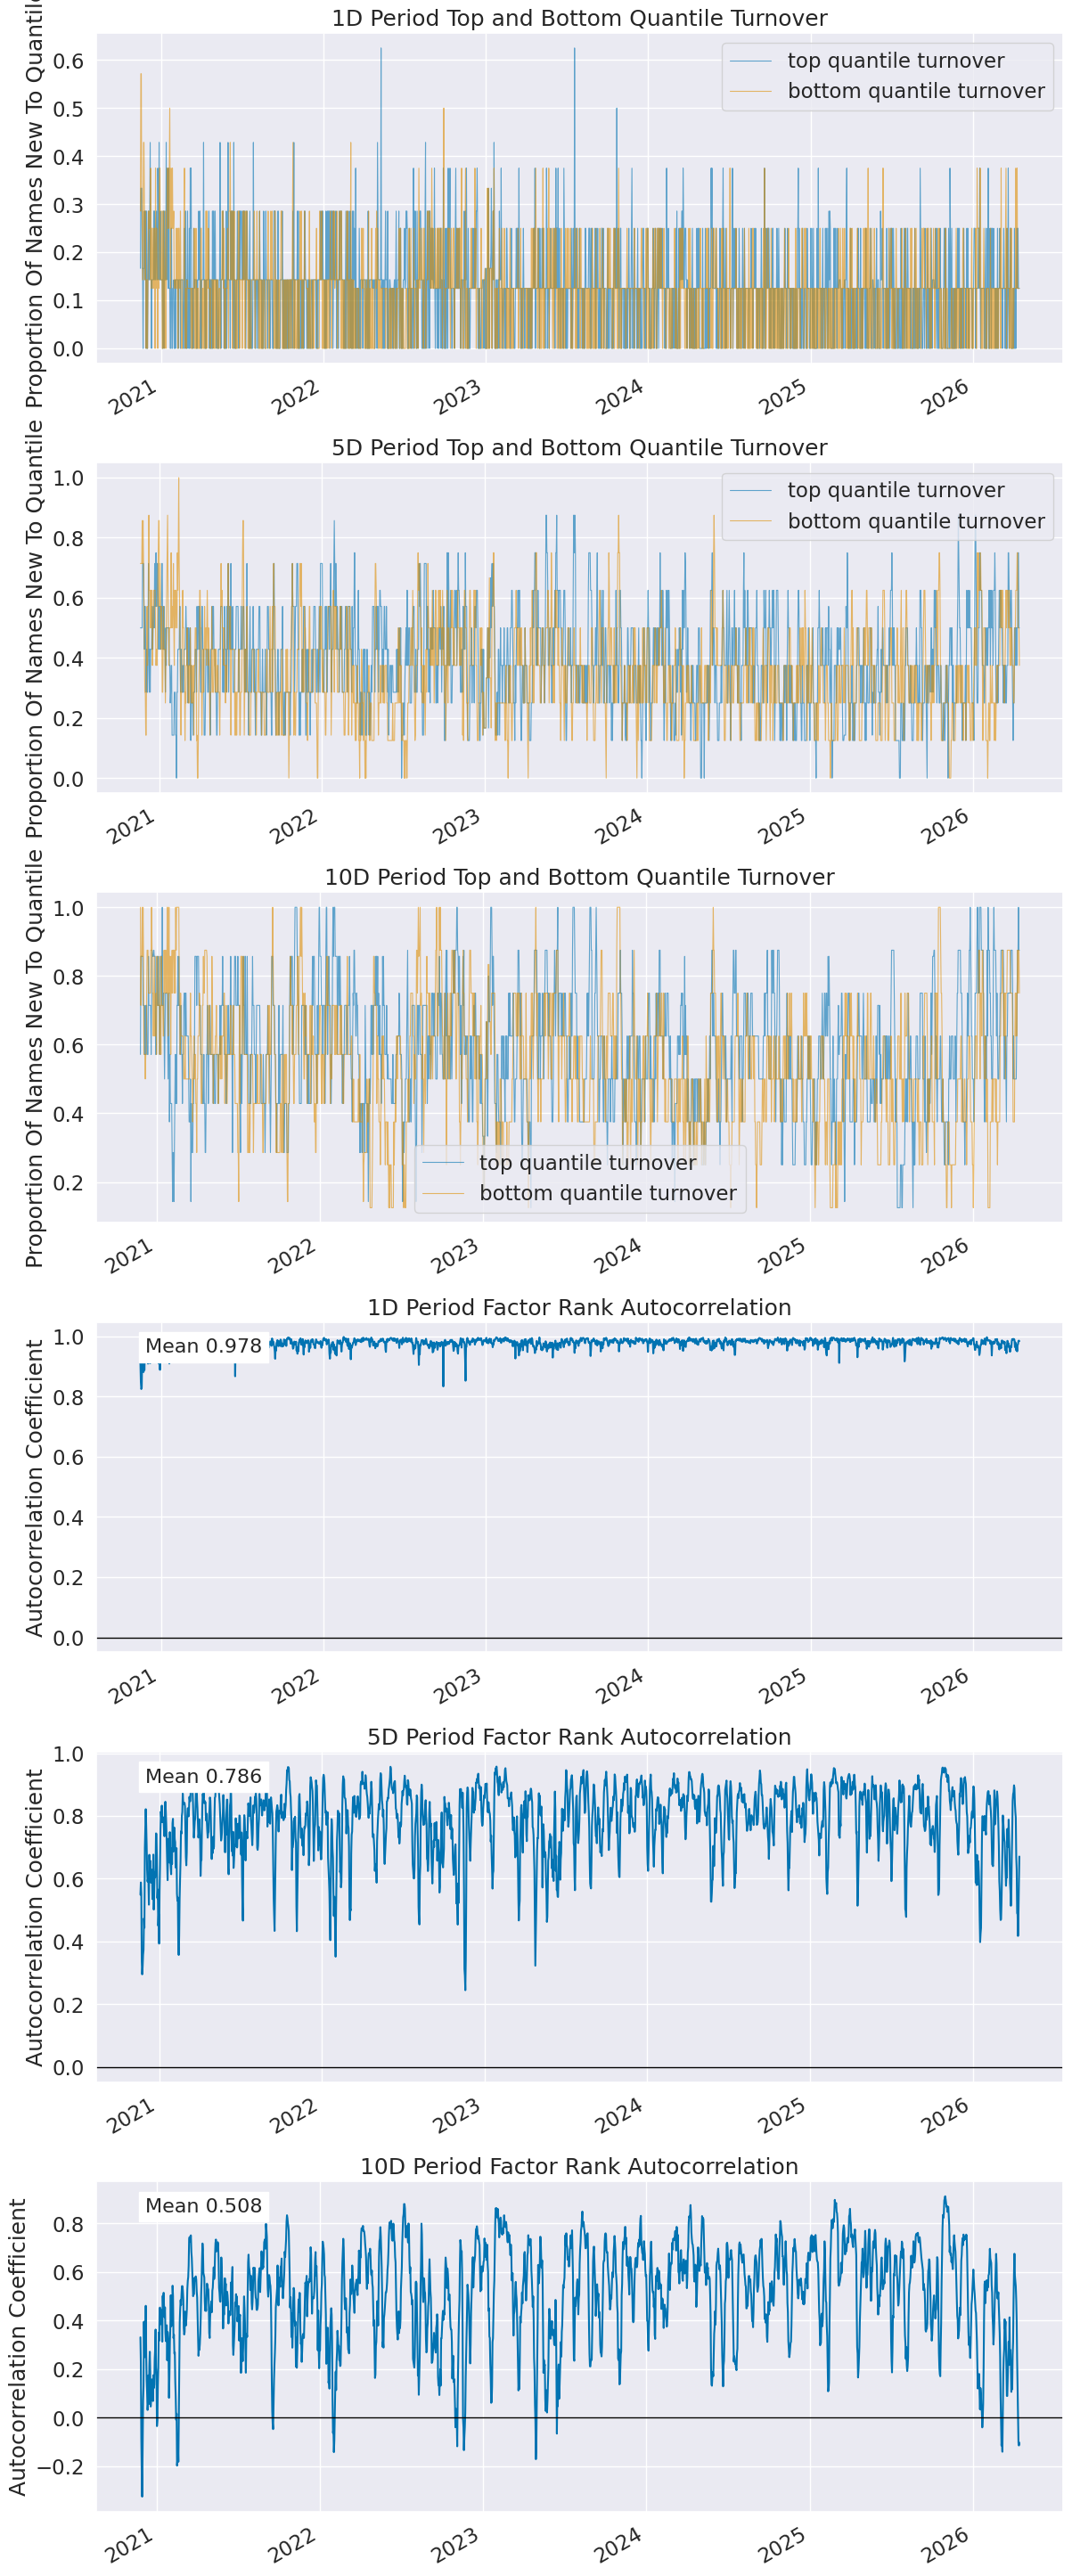

In [1]:
# AUTO-GENERATED from scripts/factors_catalog.py by
# scripts/generate_factor_notebooks.py -- do not edit by hand.
import sys
from pathlib import Path

_root = Path.cwd()
while not (_root / "notebooks" / "analysis").is_dir() and _root != _root.parent:
    _root = _root.parent
for _p in (_root, _root / "notebooks"):
    sys.path.insert(0, str(_p))

from unravel_client import (
    get_historical_universe,
    get_portfolio_factors_historical,
    get_prices,
    get_tickers,
)

from analysis.alphalens import factor_analysis
from analysis.utils import get_env

UNRAVEL_API_KEY = get_env("UNRAVEL_API_KEY")

# Retail Flow -- portfolio retail_flow.40
portfolio = "retail_flow"
universe_size = "40"

available_tickers = get_tickers(
    id=portfolio,
    api_key=UNRAVEL_API_KEY,
    universe_size=universe_size,
    exchange=None,
)
historical_factors = get_portfolio_factors_historical(
    id=portfolio, tickers=available_tickers, api_key=UNRAVEL_API_KEY
)
underlying = get_prices(tickers=available_tickers, api_key=UNRAVEL_API_KEY)

# Mask the raw factor with the dynamic point-in-time universe (a boolean
# dates x tickers matrix) so AlphaLens scores only the universe we trade,
# not every ticker that was ever tradeable.
universe = get_historical_universe(
    size=universe_size,
    api_key=UNRAVEL_API_KEY,
    start_date=str(historical_factors.index.min().date()),
    end_date=str(historical_factors.index.max().date()),
)
membership = (
    universe.reindex(index=historical_factors.index)
    .ffill()
    .reindex(columns=historical_factors.columns)
    .fillna(False)
    .astype(bool)
)
restricted_factors = historical_factors.where(membership)

columns_intersection = restricted_factors.columns.intersection(underlying.columns)
factor_analysis(restricted_factors[columns_intersection], underlying)